# Nasdaq: Acciones de Menor Variabilidad + Predicción Prophet para META
**Objetivo:** Identificar las acciones del Nasdaq-100 con menor volatilidad histórica y generar una predicción de Meta Platforms (META) con Prophet al 95% de confianza.

In [16]:
# Instalar dependencias si es necesario
# !pip install yfinance prophet pandas numpy matplotlib seaborn plotly

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Descarga de datos — Nasdaq-100
Usamos los 100 tickers principales del índice Nasdaq-100. Los datos cubren los últimos 3 años.

In [4]:
# Tickers del Nasdaq-100 (composición aproximada vigente)
NASDAQ_100_TICKERS = [
    'AAPL', 'MSFT', 'NVDA', 'AMZN', 'META', 'GOOGL', 'GOOG', 'TSLA', 'AVGO', 'COST',
    'NFLX', 'ASML', 'AMD', 'ADBE', 'QCOM', 'PEP', 'AMAT', 'CSCO', 'TMUS', 'INTC',
    'INTU', 'TXN', 'AMGN', 'ISRG', 'BKNG', 'VRTX', 'MU', 'LRCX', 'REGN', 'KLAC',
    'SNPS', 'CDNS', 'MDLZ', 'MELI', 'PANW', 'ADI', 'CTAS', 'CRWD', 'ORLY', 'FTNT',
    'NXPI', 'MRVL', 'MAR', 'MNST', 'ABNB', 'DXCM', 'WDAY', 'PYPL', 'PAYX', 'PCAR',
    'AZN', 'CHTR', 'FAST', 'ROST', 'ODFL', 'KDP', 'VRSK', 'CPRT', 'CSGP', 'TEAM',
    'ZS', 'DLTR', 'EXC', 'CEG', 'XEL', 'IDXX', 'FANG', 'ON', 'GFS', 'GEHC',
    'EA', 'DDOG', 'LULU', 'BKR', 'SIRI', 'WBA', 'ALGN', 'TTWO', 'ZM', 'ILMN',
    'BIIB', 'MRNA', 'OKTA', 'EBAY', 'ANSS', 'WBD', 'ENPH', 'LCID', 'RIVN', 'DOCU',
    'CDW', 'CINF', 'CSX', 'GILD', 'HON', 'KHC', 'MCHP', 'SBUX', 'VRSN', 'VTRS'
]

PERIOD = '3y'
print(f'Descargando datos para {len(NASDAQ_100_TICKERS)} tickers ({PERIOD})...')

raw = yf.download(
    NASDAQ_100_TICKERS,
    period=PERIOD,
    auto_adjust=True,
    progress=False
)['Close']

raw.dropna(axis=1, thresh=int(len(raw) * 0.9), inplace=True)
print(f'Datos descargados: {raw.shape[0]} días × {raw.shape[1]} acciones')
raw.tail(3)

Descargando datos para 100 tickers (3y)...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ANSS"}}}
$ANSS: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: WBA"}}}
$WBA: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")

2 Failed downloads:
['ANSS', 'WBA']: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")


Datos descargados: 753 días × 98 acciones


Ticker,AAPL,ABNB,ADBE,ADI,ALGN,AMAT,AMD,AMGN,AMZN,ASML,...,TXN,VRSK,VRSN,VRTX,VTRS,WBD,WDAY,XEL,ZM,ZS
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-16,299.239990,141.199997,207.320007,416.000000,179.520004,568.229980,507.290009,347.839996,246.000000,1803.890015,...,305.709991,179.610001,273.869995,453.170013,16.040001,26.600000,126.769997,78.980003,92.070000,127.230003
2026-06-17,295.950012,140.539993,196.279999,414.450012,173.529999,592.919983,512.479980,341.660004,237.500000,1867.829956,...,301.880005,175.350006,264.920013,458.989990,15.730000,26.240000,121.830002,77.459999,87.389999,124.379997
2026-06-18,298.010010,142.410004,195.160004,434.459991,182.080002,617.109985,537.369995,337.600006,244.389999,1929.680054,...,322.859985,173.800003,264.640015,451.630005,15.370000,26.200001,116.930000,77.410004,86.360001,124.849998


## 2. Cálculo de Volatilidad
Usamos dos métricas complementarias:
- **Volatilidad anualizada**: desviación estándar de los retornos diarios × √252
- **Coeficiente de variación (CV)**: std / media del precio × 100 (mide dispersión relativa)

In [5]:
daily_returns = raw.pct_change().dropna()

volatility = pd.DataFrame({
    'vol_anualizada_pct': (daily_returns.std() * np.sqrt(252) * 100).round(2),
    'cv_pct':             ((raw.std() / raw.mean()) * 100).round(2),
    'retorno_total_pct':  (((raw.iloc[-1] / raw.iloc[0]) - 1) * 100).round(2),
    'precio_actual':      raw.iloc[-1].round(2)
})

volatility.sort_values('vol_anualizada_pct', inplace=True)
volatility.index.name = 'Ticker'

print('Top 20 acciones con MENOR volatilidad anualizada:')
volatility.head(20)

Top 20 acciones con MENOR volatilidad anualizada:


,vol_anualizada_pct,cv_pct,retorno_total_pct,precio_actual
Ticker,,,,
PEP,19.48,7.51,-14.90,142.02
EXC,19.68,12.39,25.86,45.81
COST,19.89,19.58,90.56,951.45
MDLZ,20.26,7.12,-10.77,60.12
XEL,20.63,16.00,35.93,77.41
ORLY,21.11,16.70,41.97,86.84
CTAS,21.60,17.35,44.85,170.85
HON,21.97,9.68,29.32,229.01
CINF,22.07,18.54,84.24,170.20


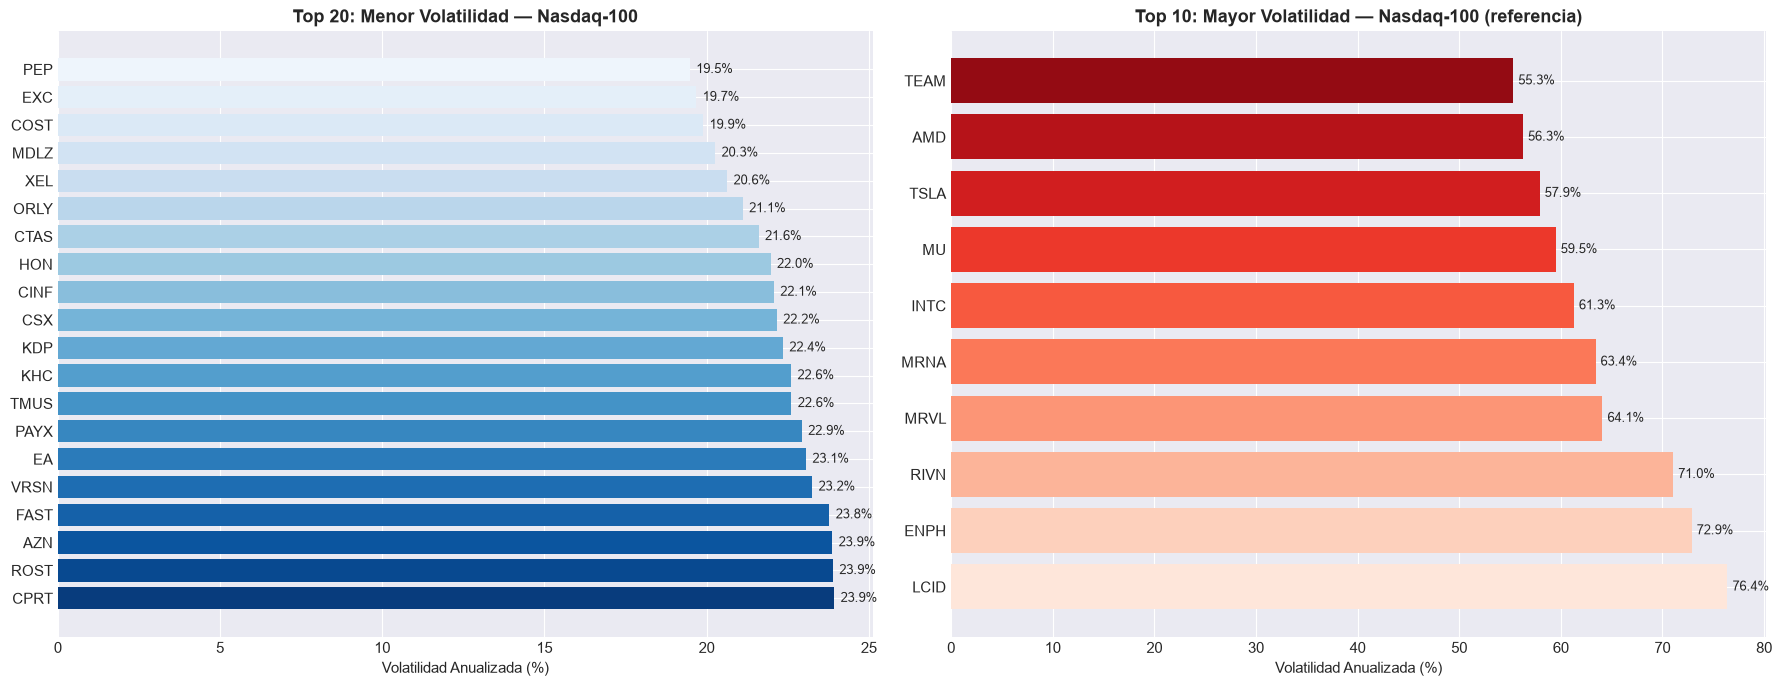

Gráfico guardado como volatilidad_nasdaq.png


In [6]:
top_low_vol = volatility.head(20).copy()
top_high_vol = volatility.tail(10).copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Menor volatilidad
colors_low = sns.color_palette('Blues_r', n_colors=20)
axes[0].barh(top_low_vol.index[::-1], top_low_vol['vol_anualizada_pct'][::-1], color=colors_low)
axes[0].set_xlabel('Volatilidad Anualizada (%)')
axes[0].set_title('Top 20: Menor Volatilidad — Nasdaq-100', fontweight='bold')
for i, (idx, row) in enumerate(top_low_vol.iloc[::-1].iterrows()):
    axes[0].text(row['vol_anualizada_pct'] + 0.2, i, f"{row['vol_anualizada_pct']:.1f}%", va='center', fontsize=9)

# Mayor volatilidad (referencia)
colors_high = sns.color_palette('Reds', n_colors=10)
axes[1].barh(top_high_vol.index[::-1], top_high_vol['vol_anualizada_pct'][::-1], color=colors_high)
axes[1].set_xlabel('Volatilidad Anualizada (%)')
axes[1].set_title('Top 10: Mayor Volatilidad — Nasdaq-100 (referencia)', fontweight='bold')
for i, (idx, row) in enumerate(top_high_vol.iloc[::-1].iterrows()):
    axes[1].text(row['vol_anualizada_pct'] + 0.5, i, f"{row['vol_anualizada_pct']:.1f}%", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('volatilidad_nasdaq.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado como volatilidad_nasdaq.png')

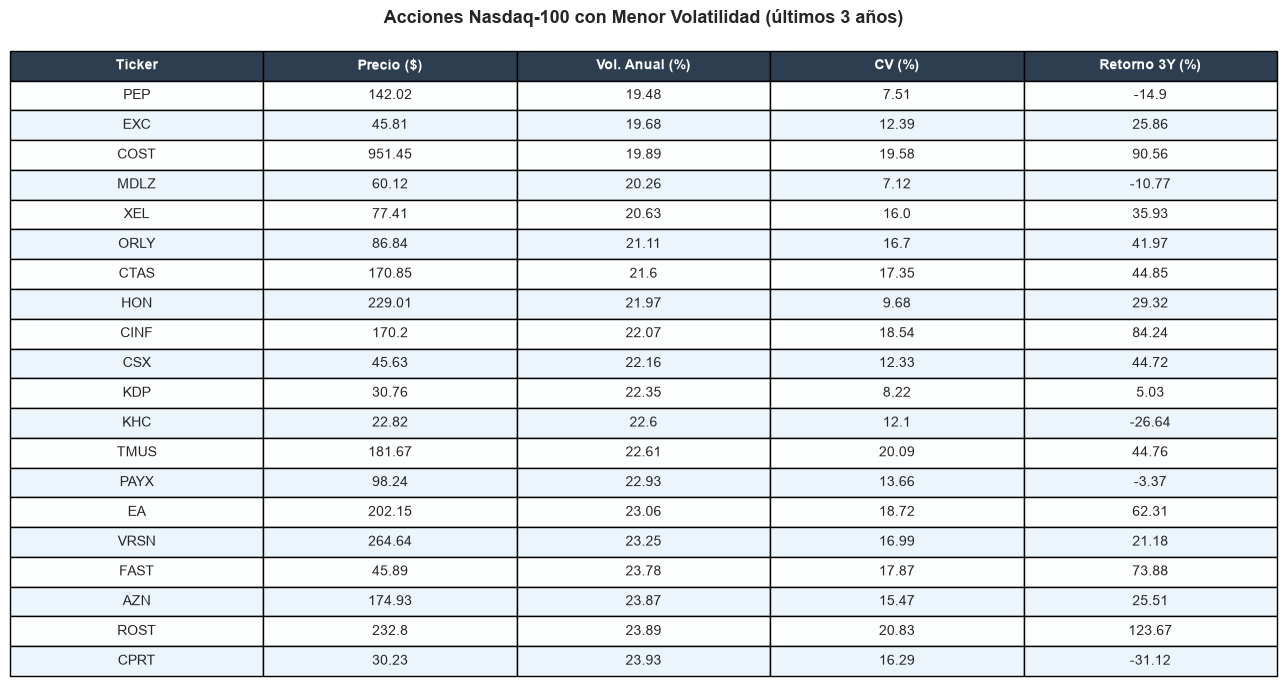

In [7]:
# Tabla resumen de los 20 menos volátiles con retorno
fig, ax = plt.subplots(figsize=(13, 7))
ax.axis('off')

display_df = top_low_vol.reset_index()[[
    'Ticker', 'precio_actual', 'vol_anualizada_pct', 'cv_pct', 'retorno_total_pct'
]].rename(columns={
    'precio_actual': 'Precio ($)',
    'vol_anualizada_pct': 'Vol. Anual (%)',
    'cv_pct': 'CV (%)',
    'retorno_total_pct': 'Retorno 3Y (%)'
})

table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(10)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#EBF5FB')
    else:
        cell.set_facecolor('#FDFEFE')

ax.set_title('Acciones Nasdaq-100 con Menor Volatilidad (últimos 3 años)', 
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('tabla_volatilidad.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Predicción Prophet — Meta Platforms (META)
Entrenamos un modelo Prophet con datos históricos de META y generamos una predicción a 365 días con **intervalo de confianza del 95%**.

In [8]:
from prophet import Prophet

# Descarga histórica extendida para mejor entrenamiento
meta_raw = yf.download('META', period='5y', auto_adjust=True, progress=False)['Close']
meta_raw = meta_raw.reset_index()
meta_raw.columns = ['ds', 'y']
meta_raw['ds'] = pd.to_datetime(meta_raw['ds']).dt.tz_localize(None)

print(f'Datos META: {meta_raw.shape[0]} registros')
print(f'Rango: {meta_raw["ds"].min().date()} → {meta_raw["ds"].max().date()}')
print(f'Precio más reciente: ${meta_raw["y"].iloc[-1]:.2f}')
meta_raw.tail(3)

Datos META: 1255 registros
Rango: 2021-06-21 → 2026-06-18
Precio más reciente: $577.22


,ds,y
1252,2026-06-16,600.210022
1253,2026-06-17,567.580017
1254,2026-06-18,577.219971


In [9]:
# Configuración del modelo Prophet
model = Prophet(
    interval_width=0.95,          # Intervalo de confianza al 95%
    changepoint_prior_scale=0.05, # Sensibilidad a cambios de tendencia
    seasonality_prior_scale=10,   # Peso de estacionalidades
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative'  # Mejor para activos financieros
)

# Añadir regresor de mercado: log del precio para capturar tendencia exponencial
model.fit(meta_raw)
print('Modelo entrenado correctamente.')

15:21:37 - cmdstanpy - INFO - Chain [1] start processing
15:21:38 - cmdstanpy - INFO - Chain [1] done processing


Modelo entrenado correctamente.


In [10]:
FORECAST_DAYS = 365

future = model.make_future_dataframe(periods=FORECAST_DAYS, freq='B')  # freq='B' = días hábiles
forecast = model.predict(future)

# Últimas filas de la predicción
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(5).round(2)

,ds,yhat,yhat_lower,yhat_upper
1615,2027-11-05,423.47,-2299.19,3323.62
1616,2027-11-08,416.73,-2285.92,3252.01
1617,2027-11-09,414.29,-2235.32,3276.77
1618,2027-11-10,412.89,-2276.23,3264.45
1619,2027-11-11,410.49,-2298.92,3264.67


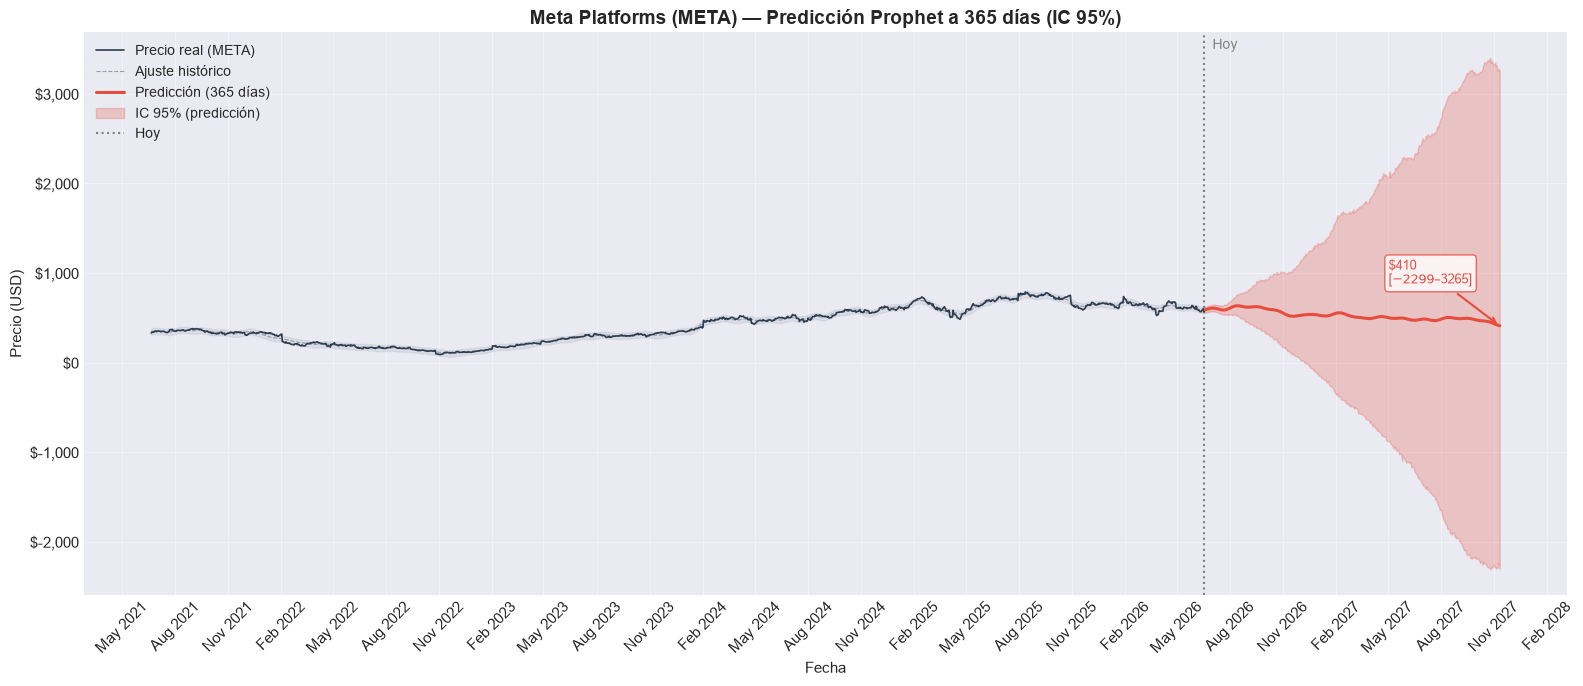

Gráfico guardado como meta_prophet_forecast.png


In [11]:
# --- Gráfico principal de predicción ---
fig, ax = plt.subplots(figsize=(16, 7))

cutoff = meta_raw['ds'].max()
hist = forecast[forecast['ds'] <= cutoff]
pred = forecast[forecast['ds'] > cutoff]

# Datos históricos reales
ax.plot(meta_raw['ds'], meta_raw['y'], color='#2C3E50', linewidth=1.2, label='Precio real (META)', zorder=3)

# Línea de predicción histórica (fitted)
ax.plot(hist['ds'], hist['yhat'], color='#5D6D7E', linewidth=0.8, linestyle='--', alpha=0.6, label='Ajuste histórico')

# Predicción futura
ax.plot(pred['ds'], pred['yhat'], color='#E74C3C', linewidth=2.2, label='Predicción (365 días)', zorder=4)

# Intervalo de confianza 95% — zona futura
ax.fill_between(
    pred['ds'], pred['yhat_lower'], pred['yhat_upper'],
    alpha=0.25, color='#E74C3C', label='IC 95% (predicción)'
)

# Intervalo de confianza 95% — zona histórica
ax.fill_between(
    hist['ds'], hist['yhat_lower'], hist['yhat_upper'],
    alpha=0.1, color='#5D6D7E'
)

# Línea vertical de corte
ax.axvline(x=cutoff, color='gray', linestyle=':', linewidth=1.5, label='Hoy')
ax.text(cutoff, ax.get_ylim()[1] * 0.95, '  Hoy', color='gray', fontsize=10)

# Anotación precio final predicho
final_pred = pred.iloc[-1]
ax.annotate(
    f"${final_pred['yhat']:.0f}\n[${final_pred['yhat_lower']:.0f} – ${final_pred['yhat_upper']:.0f}]",
    xy=(final_pred['ds'], final_pred['yhat']),
    xytext=(-80, 30), textcoords='offset points',
    fontsize=9, color='#E74C3C',
    arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#E74C3C', alpha=0.8)
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)

ax.set_title('Meta Platforms (META) — Predicción Prophet a 365 días (IC 95%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio (USD)')
ax.legend(loc='upper left', fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('meta_prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado como meta_prophet_forecast.png')

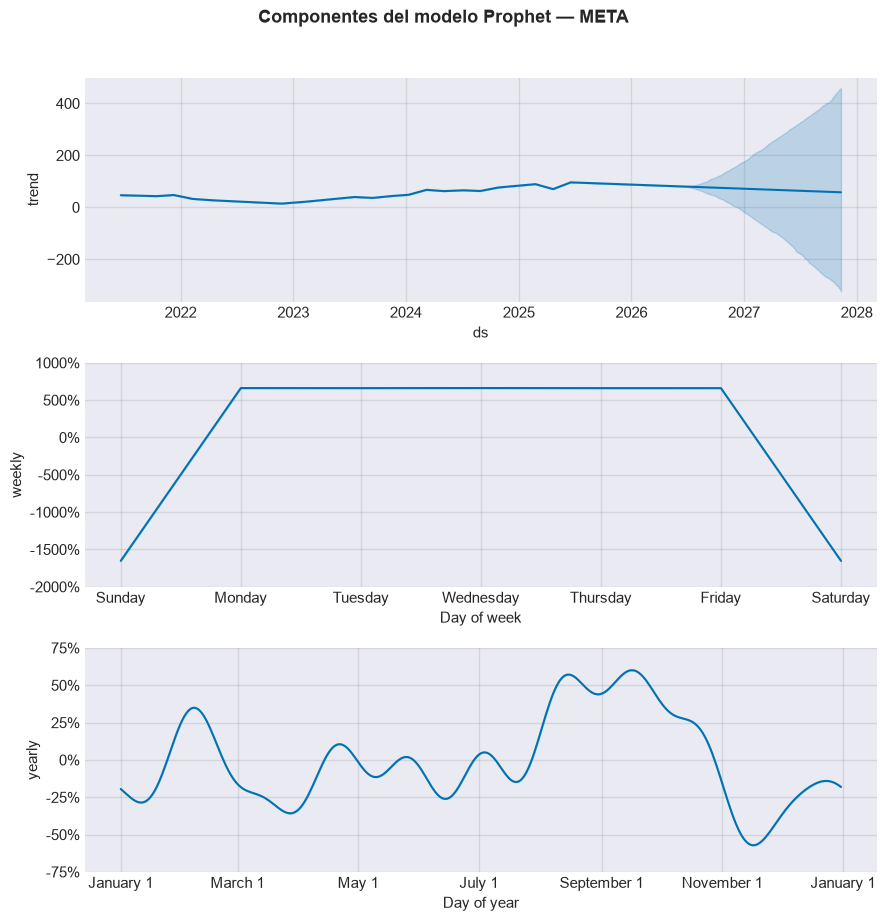

Componentes guardados como meta_prophet_components.png


In [12]:
# --- Componentes de la predicción (tendencia + estacionalidades) ---
fig_comp = model.plot_components(forecast)
fig_comp.suptitle('Componentes del modelo Prophet — META', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('meta_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()
print('Componentes guardados como meta_prophet_components.png')

In [13]:
# --- Resumen cuantitativo ---
precio_actual = meta_raw['y'].iloc[-1]
pred_30  = forecast[forecast['ds'] > cutoff].iloc[21]   # ~1 mes
pred_90  = forecast[forecast['ds'] > cutoff].iloc[64]   # ~3 meses
pred_180 = forecast[forecast['ds'] > cutoff].iloc[129]  # ~6 meses
pred_365 = forecast[forecast['ds'] > cutoff].iloc[-1]   # ~12 meses

def fmt_row(label, row):
    change = (row['yhat'] / precio_actual - 1) * 100
    return {
        'Horizonte': label,
        'Fecha estimada': row['ds'].strftime('%Y-%m-%d'),
        'Precio central ($)': f"{row['yhat']:.2f}",
        'IC inferior 95% ($)': f"{row['yhat_lower']:.2f}",
        'IC superior 95% ($)': f"{row['yhat_upper']:.2f}",
        'Cambio vs hoy (%)': f"{change:+.1f}%"
    }

summary = pd.DataFrame([
    fmt_row('1 mes',  pred_30),
    fmt_row('3 meses', pred_90),
    fmt_row('6 meses', pred_180),
    fmt_row('12 meses', pred_365),
])

print(f'\nPrecio actual de META: ${precio_actual:.2f}')
print('\nResumen de predicciones Prophet (IC 95%):')
summary


Precio actual de META: $577.22

Resumen de predicciones Prophet (IC 95%):


,Horizonte,Fecha estimada,Precio central ($),IC inferior 95% ($),IC superior 95% ($),Cambio vs hoy (%)
0,1 mes,2026-07-20,587.14,538.77,632.00,+1.7%
1,3 meses,2026-09-17,624.39,382.59,898.38,+8.2%
2,6 meses,2026-12-17,536.42,-42.39,1254.62,-7.1%
3,12 meses,2027-11-11,410.49,-2298.92,3264.67,-28.9%


## 4. Comparativa: META vs las acciones menos volátiles del Nasdaq
¿Cómo se posiciona META en el ranking de volatilidad?

In [14]:
meta_rank = volatility.reset_index()
meta_rank['rank'] = range(1, len(meta_rank) + 1)
meta_row = meta_rank[meta_rank['Ticker'] == 'META']

if not meta_row.empty:
    r = meta_row.iloc[0]
    print(f"META en el ranking de volatilidad del Nasdaq-100:")
    print(f"  Posición: #{int(r['rank'])} de {len(meta_rank)} acciones")
    print(f"  Volatilidad anualizada: {r['vol_anualizada_pct']:.1f}%")
    print(f"  Coeficiente de variación: {r['cv_pct']:.1f}%")
    print(f"  Retorno total 3Y: {r['retorno_total_pct']:+.1f}%")
else:
    print('META no encontrada en el ranking (puede ser por falta de datos).')

META en el ranking de volatilidad del Nasdaq-100:
  Posición: #55 de 98 acciones
  Volatilidad anualizada: 36.5%
  Coeficiente de variación: 25.9%
  Retorno total 3Y: +104.8%


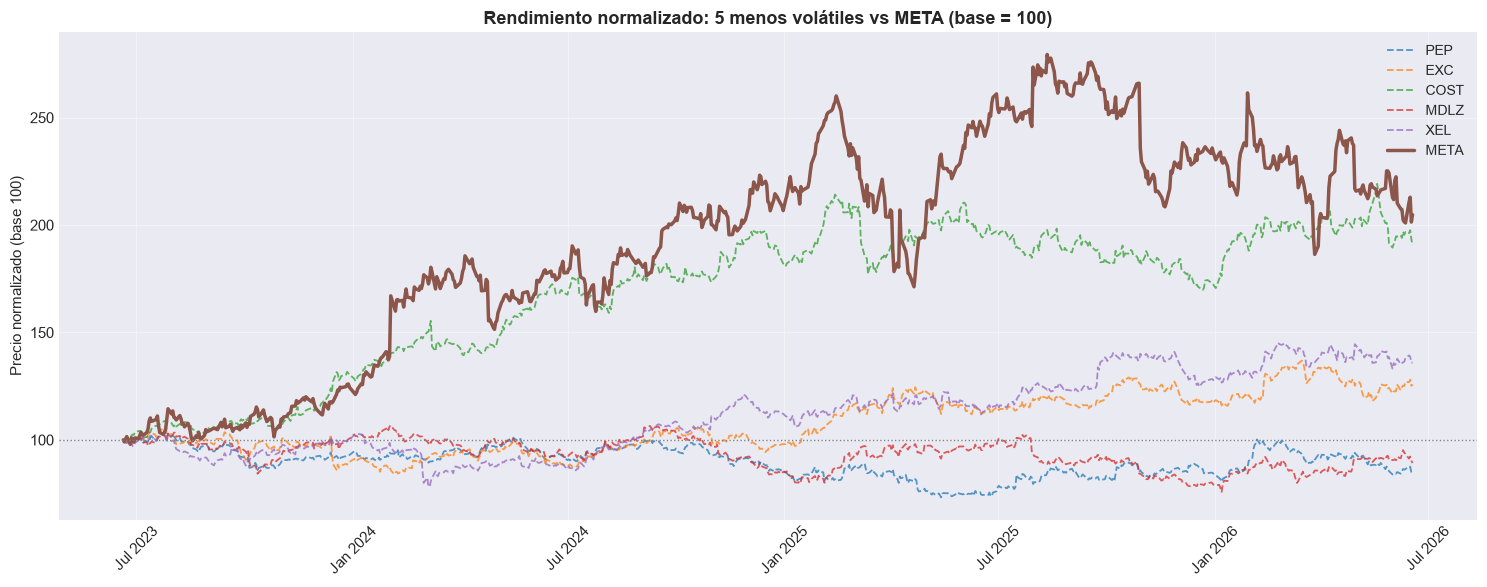

In [15]:
# Precio normalizado: los 5 menos volátiles vs META
top5 = volatility.head(5).index.tolist()
tickers_compare = top5 + ['META']
prices_compare = raw[tickers_compare].dropna()
normalized = (prices_compare / prices_compare.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(15, 6))
palette = sns.color_palette('tab10', n_colors=len(tickers_compare))

for i, ticker in enumerate(tickers_compare):
    lw = 2.5 if ticker == 'META' else 1.3
    ls = '-' if ticker == 'META' else '--'
    alpha = 1.0 if ticker == 'META' else 0.75
    ax.plot(normalized.index, normalized[ticker], label=ticker,
            linewidth=lw, linestyle=ls, color=palette[i], alpha=alpha)

ax.axhline(100, color='gray', linestyle=':', linewidth=1)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
ax.set_title('Rendimiento normalizado: 5 menos volátiles vs META (base = 100)', fontsize=13, fontweight='bold')
ax.set_ylabel('Precio normalizado (base 100)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('comparativa_volatilidad.png', dpi=150, bbox_inches='tight')
plt.show()

---
### Notas metodológicas
- **Volatilidad anualizada** = σ(retornos diarios) × √252. Estándar en finanzas para comparar activos.
- **Prophet** está diseñado para series temporales con patrones estacionales. Su aplicación a acciones captura tendencias y ciclos, pero **no factores macroeconómicos ni eventos exógenos**.
- El **IC del 95%** indica que, bajo los supuestos del modelo, el precio futuro caerá dentro de la banda en el 95% de los escenarios simulados por Prophet.
- Este análisis es **solo educativo** y no constituye asesoramiento financiero.